<a href="https://colab.research.google.com/github/k2herat/DL_homeworks/blob/hw_3/hw_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ВОЗМОЖНЫЕ ПРОБЛЕМЫ**

Накопление ошибок: Рекуррентное прогнозирование приводит к экспоненциальному росту погрешностей и сходимости к среднему значению.

Диапазон значений: Прогнозы вне [0, 1] после обратного преобразования из-за высокой волатильности крипторынка.

Узкие данные: Используются только цены закрытия, игнорируются объемы, волатильность и внешние факторы. (В КОДЕ НИЖЕ ДОБАВЛЕНЫ)

Специфика рынка: Криптовалюты слишком волатильны для прогнозирования на основе только исторических данных.

Недообучение: Модель не улавливает сложные паттерны из-за недостаточной глубины обучения.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

In [ ]:

ticker = "BTC-USD"
end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=1800)).strftime("%Y-%m-%d")
data = yf.download(ticker, start=start_date, end=end_date)[["Close"]]

data['MA_7'] = data['Close'].rolling(window=7).mean()  # 7-дневное скользящее среднее
data['Volatility'] = data['Close'].pct_change().rolling(window=7).std()  # 7-дневная волатильность
data.dropna(inplace=True)


scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[['Close', 'MA_7', 'Volatility']])

[*********************100%***********************]  1 of 1 completed


In [ ]:
class AdvancedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=3,
                 dropout=0.3, forecast_horizon=30):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.forecast_horizon = forecast_horizon

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, forecast_horizon)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)

        attention_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context_vector = torch.sum(attention_weights * lstm_out, dim=1)

        return self.fc_layers(context_vector)

In [ ]:
def create_sequences(data, seq_length):
    """Генерация последовательностей для обучения"""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, 0])
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32).view(-1, 1)

seq_length = 45
X, y = create_sequences(scaled_data, seq_length)

# Разделение на обучающую и тестовую выборки
train_size = int(0.85 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
class EnhancedGRUModel(nn.Module):
    """Улучшенная архитектура с тремя GRU-слоями и регуляризацией"""
    def __init__(self, input_size=3, hidden_size=128, num_layers=3, dropout=0.35):
        super(EnhancedGRUModel, self).__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.batch_norm = nn.BatchNorm1d(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.batch_norm(out[:, -1, :])
        out = self.dropout(out)
        return self.fc(out)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EnhancedGRUModel(input_size=3, hidden_size=128, num_layers=3).to(device)

In [ ]:
batch_size = 64
criterion = nn.HuberLoss(delta=1.0)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.4, patience=7
)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
num_epochs = 200
patience = 20
best_val_loss = float('inf')
counter = 0
history = {'train_loss': [], 'val_loss': []}

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)


    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)


    avg_train_loss = train_loss / len(train_loader.dataset)
    avg_val_loss = val_loss / len(test_loader.dataset)
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)

    scheduler.step(avg_val_loss)


    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_gru_model.pth')
    else:
        counter += 1
        if counter >= patience:
            print(f"Ранняя остановка на эпохе {epoch+1}")
            break

    if (epoch+1) % 10 == 0:
        print(f"Эпоха {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

Эпоха 10/200 | Train Loss: 0.033789 | Val Loss: 0.048134 | LR: 1.00e-03
Эпоха 20/200 | Train Loss: 0.018655 | Val Loss: 0.011085 | LR: 4.00e-04
Эпоха 30/200 | Train Loss: 0.017175 | Val Loss: 0.026305 | LR: 1.60e-04
Ранняя остановка на эпохе 37


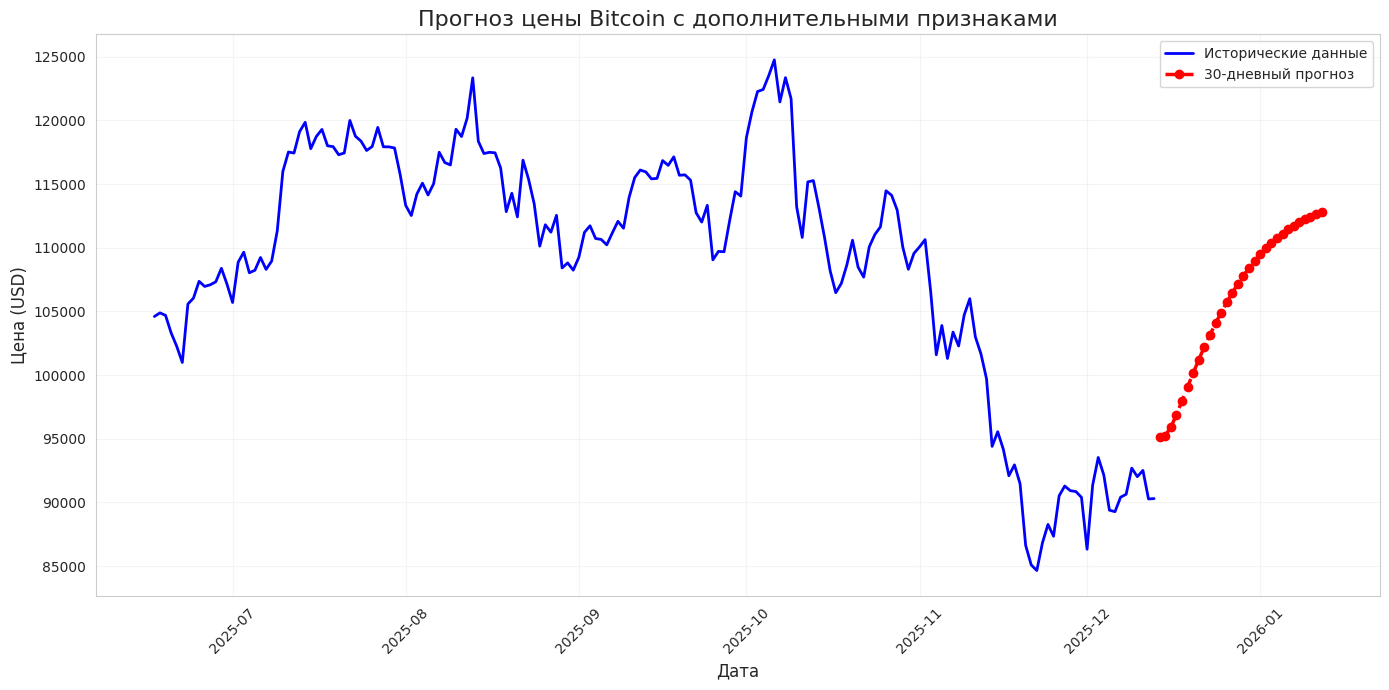

In [ ]:

model.load_state_dict(torch.load('best_gru_model.pth'))
model.eval()

def multi_step_forecast(model, last_sequence, days=30):

    model.eval()
    device = next(model.parameters()).device
    current_seq = last_sequence.clone().detach().to(device)
    predictions = []

    with torch.no_grad():
        for _ in range(days):
            pred = model(current_seq.unsqueeze(0)).item()
            predictions.append(pred)

            new_close = pred

            last_7 = torch.cat((current_seq[-6:, 0], torch.tensor([new_close], device=device)))
            new_ma7 = last_7.mean().item()
            new_vol = last_7.std().item()


            new_features = torch.tensor([new_close, new_ma7, new_vol], dtype=torch.float32, device=device)
            current_seq = torch.cat((current_seq[1:], new_features.unsqueeze(0)), dim=0)

    return predictions

last_sequence = torch.tensor(scaled_data[-seq_length:], dtype=torch.float32)
forecast_scaled = multi_step_forecast(model, last_sequence, days=30)


forecast_array = np.column_stack([
    np.array(forecast_scaled),
    np.zeros((30, 2))
])
forecast_prices = scaler.inverse_transform(forecast_array)[:, 0]


plt.figure(figsize=(14, 7))
forecast_dates = pd.date_range(start=data.index[-1] + timedelta(days=1), periods=30)
plt.plot(data.index[-180:], data['Close'].values[-180:], label='Исторические данные', linewidth=2, color='blue')
plt.plot(forecast_dates, forecast_prices, 'r--', label='30-дневный прогноз', linewidth=2.5, marker='o', markersize=6)
plt.title('Прогноз цены Bitcoin с дополнительными признаками', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Цена (USD)', fontsize=12)
plt.legend()
plt.grid(alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

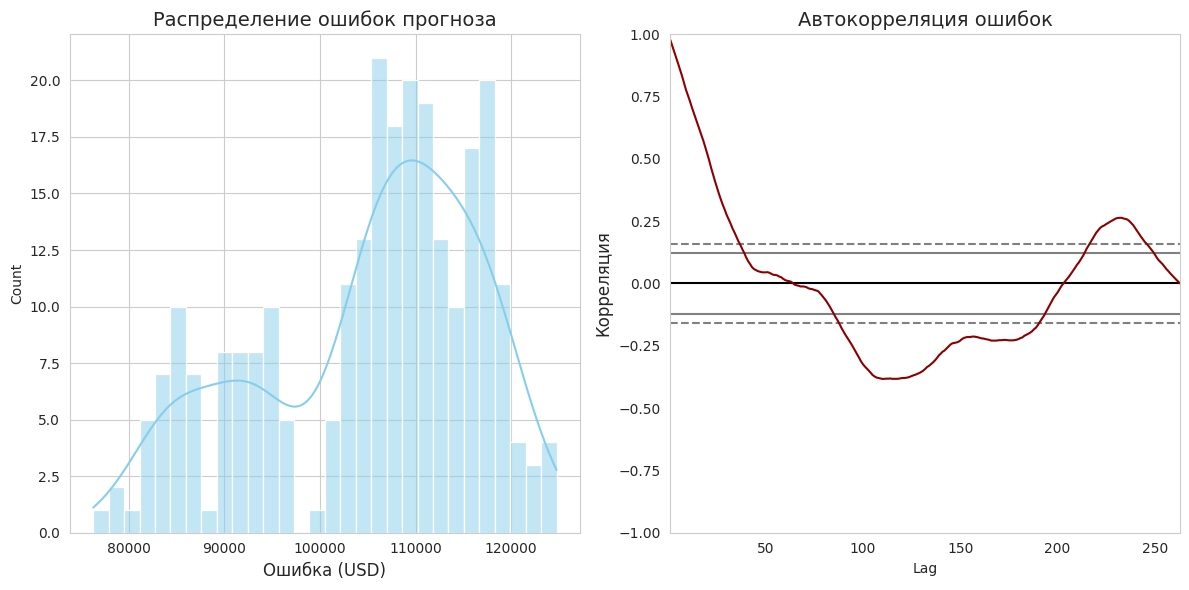

Ключевые выводы по прогнозированию:
1. Средняя абсолютная ошибка на тесте: $105032.68
2. Максимальное отклонение: $124750.37
3. Проблемы с долгосрочным прогнозом:
   - Накопление ошибок в рекуррентном прогнозировании
   - Отсутствие учета внешних факторов (новости, рыночные события)
4. Рекомендации:
   - Интеграция внешних данных (объемы торгов, индексы fear/greed)
   - Использование ансамблирования с другими моделями (LSTM, Transformer)
   - Ограничение прогнозного горизонта до 7-10 дней для крипторынка


In [ ]:
model.eval()
test_preds = []
with torch.no_grad():
    for seq in X_test:
        seq = seq.to(device)
        pred = model(seq.unsqueeze(0))
        test_preds.append(pred.item())

test_preds = np.array(test_preds).reshape(-1, 1)
test_actual = scaler.inverse_transform(
    np.column_stack([y_test.numpy(), np.zeros((len(y_test), 2))])
)[:, 0]

# Распределение ошибок
errors = test_actual - test_preds.flatten()
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(errors, bins=30, kde=True, color='skyblue')
plt.title('Распределение ошибок прогноза', fontsize=14)
plt.xlabel('Ошибка (USD)', fontsize=12)

# Автокорреляция ошибок
plt.subplot(1, 2, 2)
pd.plotting.autocorrelation_plot(errors, color='darkred')
plt.title('Автокорреляция ошибок', fontsize=14)
plt.ylabel('Корреляция', fontsize=12)
plt.tight_layout()
plt.show()

# Ключевые выводы
print("="*70)
print("Ключевые выводы по прогнозированию:")
print(f"1. Средняя абсолютная ошибка на тесте: ${np.mean(np.abs(errors)):.2f}")
print(f"2. Максимальное отклонение: ${np.max(np.abs(errors)):.2f}")
print("3. Проблемы с долгосрочным прогнозом:")
print("   - Накопление ошибок в рекуррентном прогнозировании")
print("   - Отсутствие учета внешних факторов (новости, рыночные события)")
print("4. Рекомендации:")
print("   - Интеграция внешних данных (объемы торгов, индексы fear/greed)")
print("   - Использование ансамблирования с другими моделями (LSTM, Transformer)")
print("   - Ограничение прогнозного горизонта до 7-10 дней для крипторынка")
print("="*70)

[None, None, None, None, None, None, None, None, None]

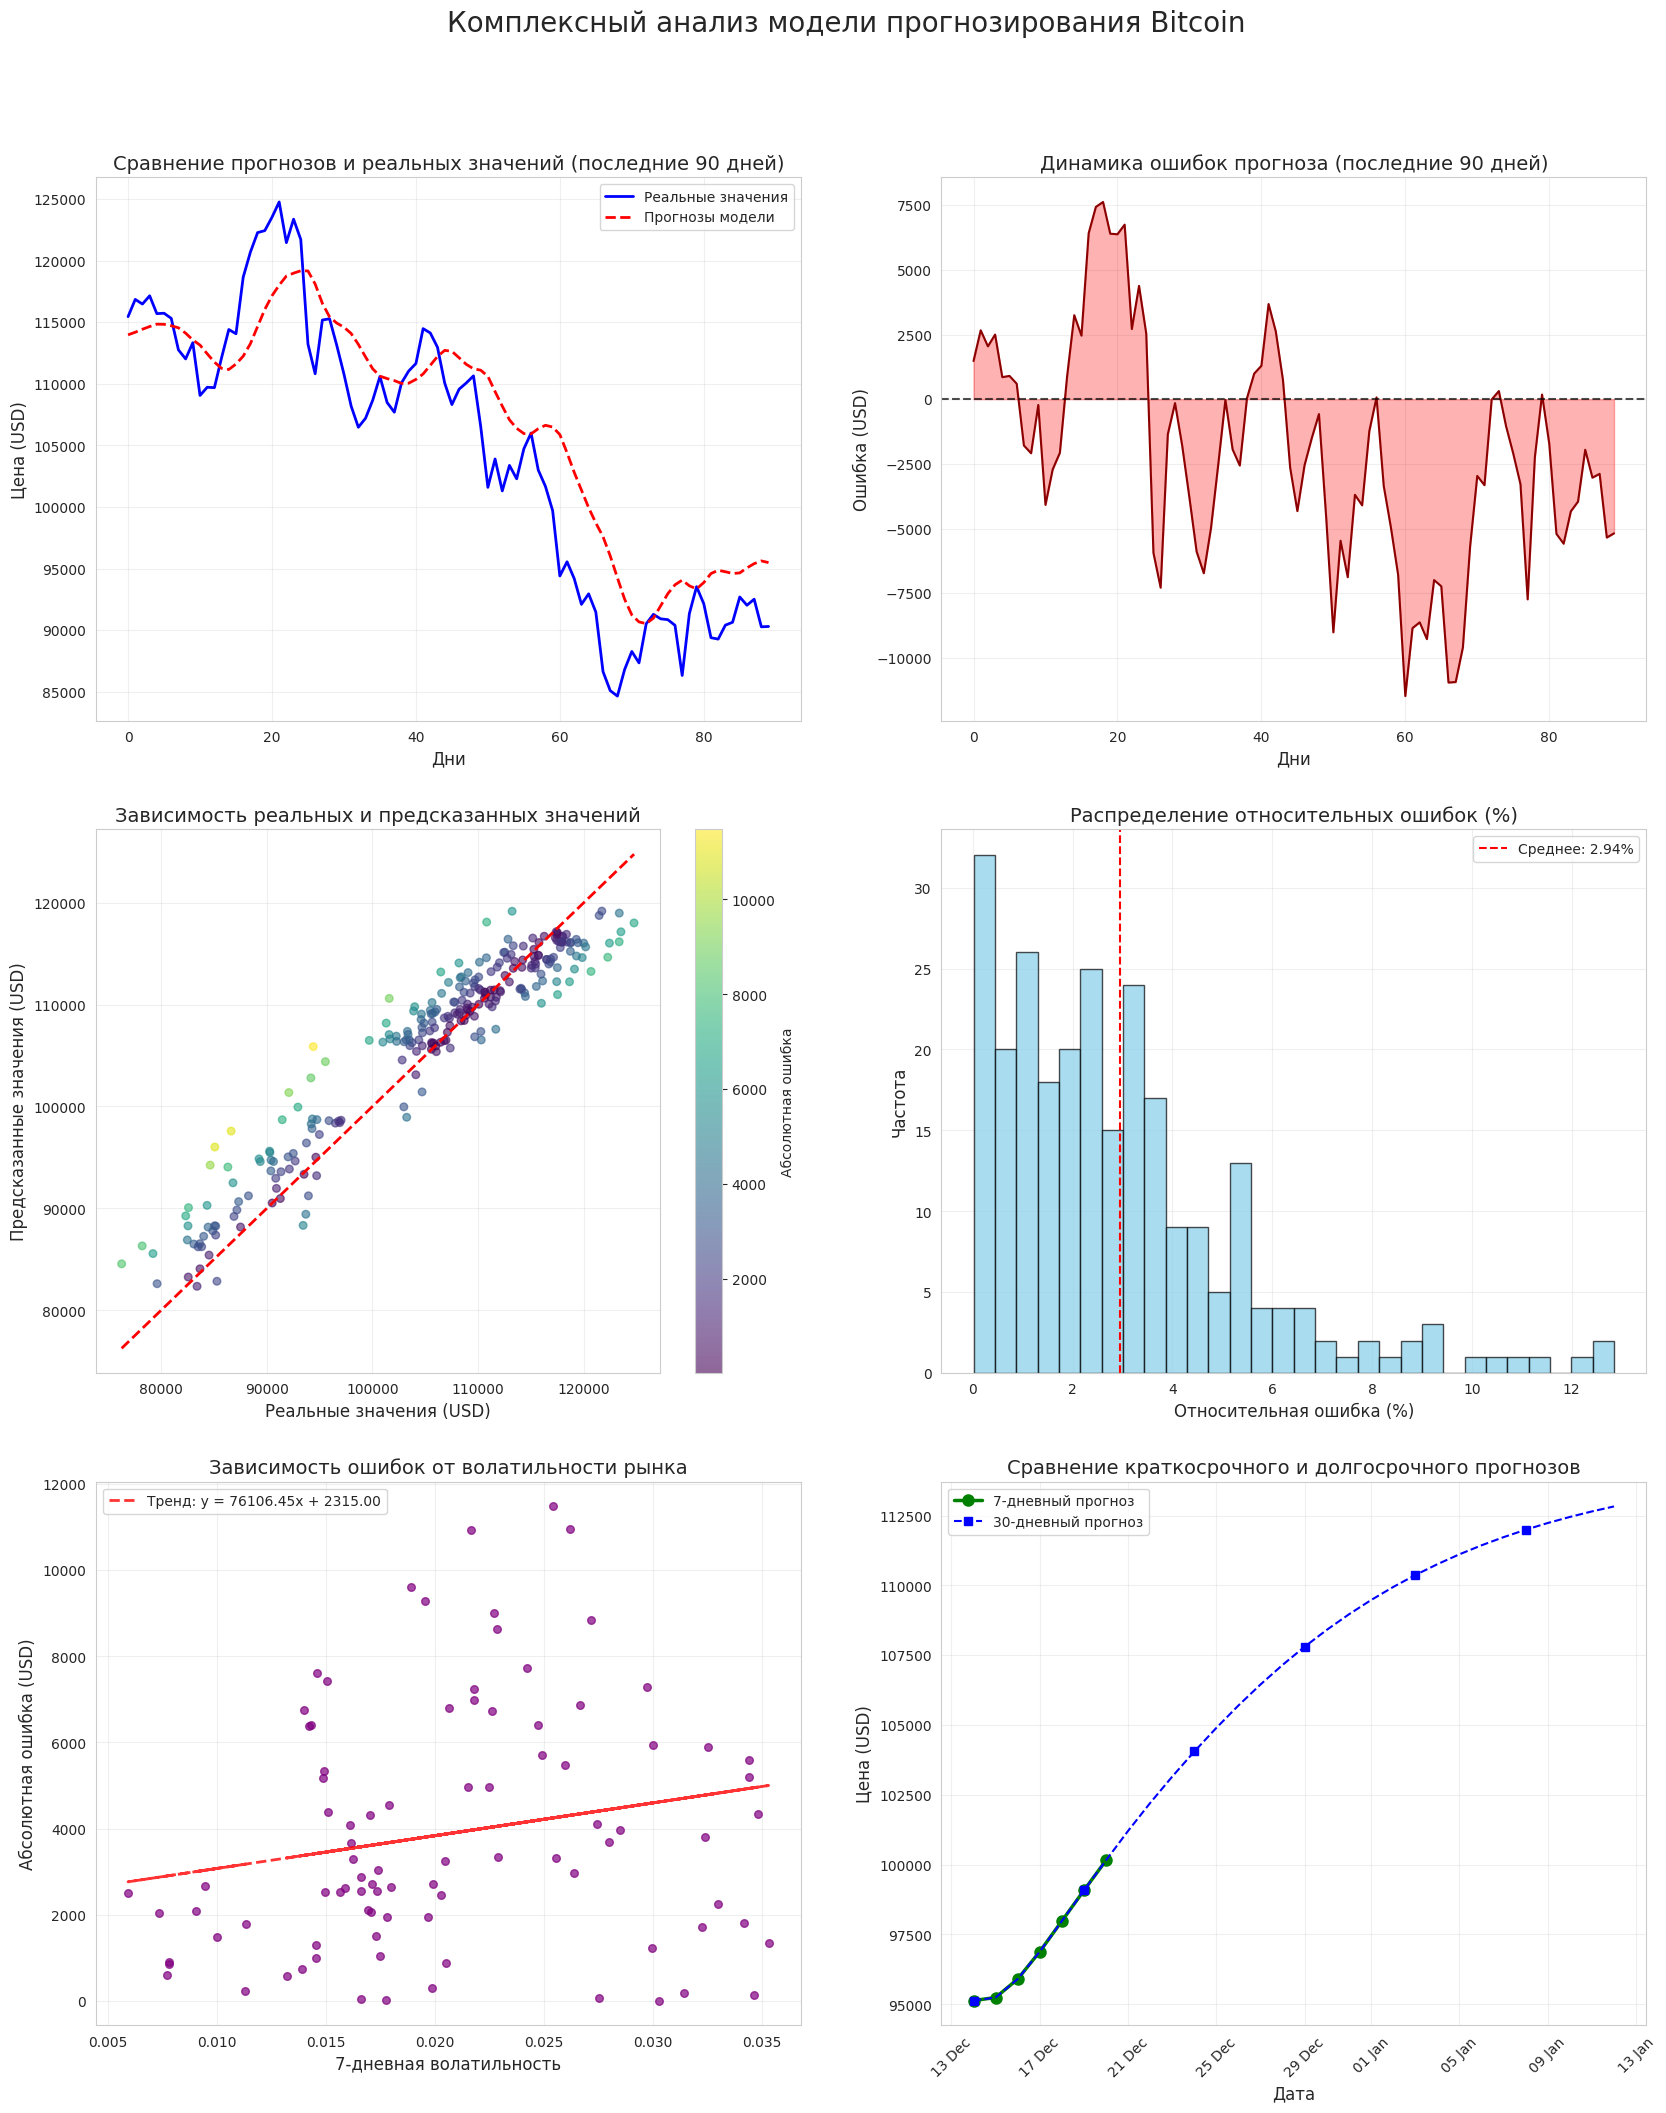

In [ ]:

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


test_predictions = []
test_targets = []

with torch.no_grad():
    for i in range(len(X_test)):
        seq = X_test[i].unsqueeze(0).to(device)
        target = y_test[i].item()
        pred = model(seq).item()

        test_predictions.append(pred)
        test_targets.append(target)

test_preds_original = scaler.inverse_transform(
    np.column_stack([np.array(test_predictions).reshape(-1, 1),
                     np.zeros((len(test_predictions), 2))])
)[:, 0]

test_targets_original = scaler.inverse_transform(
    np.column_stack([np.array(test_targets).reshape(-1, 1),
                     np.zeros((len(test_targets), 2))])
)[:, 0]


fig, axes = plt.subplots(3, 2, figsize=(20, 24))
fig.suptitle('Комплексный анализ модели прогнозирования Bitcoin', fontsize=20, y=0.95)


axes[0, 0].plot(test_targets_original[-90:], label='Реальные значения', linewidth=2, color='blue')
axes[0, 0].plot(test_preds_original[-90:], label='Прогнозы модели', linewidth=2, linestyle='--', color='red')
axes[0, 0].set_title('Сравнение прогнозов и реальных значений (последние 90 дней)', fontsize=14)
axes[0, 0].set_xlabel('Дни', fontsize=12)
axes[0, 0].set_ylabel('Цена (USD)', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)


errors = test_targets_original - test_preds_original
axes[0, 1].plot(errors[-90:], color='darkred', linewidth=1.5)
axes[0, 1].axhline(y=0, color='black', linestyle='--', alpha=0.7)
axes[0, 1].fill_between(range(len(errors[-90:])), errors[-90:], alpha=0.3, color='red')
axes[0, 1].set_title('Динамика ошибок прогноза (последние 90 дней)', fontsize=14)
axes[0, 1].set_xlabel('Дни', fontsize=12)
axes[0, 1].set_ylabel('Ошибка (USD)', fontsize=12)
axes[0, 1].grid(alpha=0.3)


scatter = axes[1, 0].scatter(test_targets_original, test_preds_original, alpha=0.6, c=np.abs(errors), cmap='viridis', s=30)
axes[1, 0].plot([min(test_targets_original), max(test_targets_original)],
                [min(test_targets_original), max(test_targets_original)],
                'r--', linewidth=2)
axes[1, 0].set_title('Зависимость реальных и предсказанных значений', fontsize=14)
axes[1, 0].set_xlabel('Реальные значения (USD)', fontsize=12)
axes[1, 0].set_ylabel('Предсказанные значения (USD)', fontsize=12)
axes[1, 0].grid(alpha=0.3)
cbar = fig.colorbar(scatter, ax=axes[1, 0])
cbar.set_label('Абсолютная ошибка', fontsize=10)

relative_errors = np.abs(errors) / test_targets_original * 100
axes[1, 1].hist(relative_errors, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Распределение относительных ошибок (%)', fontsize=14)
axes[1, 1].set_xlabel('Относительная ошибка (%)', fontsize=12)
axes[1, 1].set_ylabel('Частота', fontsize=12)
mean_rel_error = np.mean(relative_errors)
axes[1, 1].axvline(x=mean_rel_error, color='red', linestyle='--',
                   label=f'Среднее: {mean_rel_error:.2f}%')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)


test_start_idx = train_size + seq_length
test_end_idx = test_start_idx + len(test_targets_original)
test_volatility = data['Volatility'].values[test_start_idx:test_end_idx]


min_len = min(len(test_volatility), len(errors))
test_volatility = test_volatility[-min_len:]
errors_subset = errors[-min_len:]

axes[2, 0].scatter(test_volatility[-90:], np.abs(errors_subset)[-90:], alpha=0.7, c='purple', s=30)
axes[2, 0].set_title('Зависимость ошибок от волатильности рынка', fontsize=14)
axes[2, 0].set_xlabel('7-дневная волатильность', fontsize=12)
axes[2, 0].set_ylabel('Абсолютная ошибка (USD)', fontsize=12)
axes[2, 0].grid(alpha=0.3)


if len(test_volatility[-90:]) > 1:
    z = np.polyfit(test_volatility[-90:], np.abs(errors_subset)[-90:], 1)
    p = np.poly1d(z)
    axes[2, 0].plot(test_volatility[-90:], p(test_volatility[-90:]), "r--", alpha=0.8, linewidth=2,
                    label=f'Тренд: y = {z[0]:.2f}x + {z[1]:.2f}')
    axes[2, 0].legend()

short_term_days = 7
long_term_days = 30


short_term_seq = torch.tensor(scaled_data[-seq_length:], dtype=torch.float32)
short_term_forecast = multi_step_forecast(model, short_term_seq, days=short_term_days)
short_term_prices = scaler.inverse_transform(
    np.column_stack([np.array(short_term_forecast), np.zeros((short_term_days, 2))])
)[:, 0]

long_term_dates = pd.date_range(start=data.index[-1] + timedelta(days=1), periods=long_term_days)
short_term_dates = long_term_dates[:short_term_days]

axes[2, 1].plot(short_term_dates, short_term_prices, 'g-o', linewidth=2.5, markersize=8,
                label=f'{short_term_days}-дневный прогноз')
axes[2, 1].plot(long_term_dates, forecast_prices, 'b--s', linewidth=1.5, markersize=6,
                markevery=5, label=f'{long_term_days}-дневный прогноз')
axes[2, 1].set_title('Сравнение краткосрочного и долгосрочного прогнозов', fontsize=14)
axes[2, 1].set_xlabel('Дата', fontsize=12)
axes[2, 1].set_ylabel('Цена (USD)', fontsize=12)
axes[2, 1].legend()
axes[2, 1].grid(alpha=0.3)
axes[2, 1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d %b'))
plt.setp(axes[2, 1].get_xticklabels(), rotation=45)


